# Classifier Calibration Comparison (Single Seed)

Compare the Random Forest baseline and EM-EQF classifier from `classifier_baseline.ipynb` using:

- Brier score on the test split
- Reliability diagrams with uniform probability bins

This notebook intentionally evaluates one seed only (`SINGLE_SEED = 0` by default). It does not aggregate over multiple seeds or compute bootstrap confidence intervals.

## 1) Setup

In [1]:
import sys
from pathlib import Path

import matplotlib.pyplot as plt

SANS_SERIF_FONTS = ['Arial', 'Helvetica', 'Liberation Sans', 'Nimbus Sans', 'DejaVu Sans']
plt.rcParams.update({
    'font.family': 'sans-serif',
    'font.sans-serif': SANS_SERIF_FONTS,
    'mathtext.fontset': 'dejavusans',
})
import numpy as np
import pandas as pd
import torch
from IPython.display import display
from omegaconf import OmegaConf
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import brier_score_loss


def find_project_root(start: Path | None = None) -> Path:
    start = (start or Path.cwd()).resolve()
    for candidate in (start, *start.parents):
        if (candidate / 'pyproject.toml').exists() and (candidate / 'src').exists():
            return candidate
    raise RuntimeError(f'Could not locate project root from {start}')


PROJECT_ROOT = find_project_root()
if str(PROJECT_ROOT) not in sys.path:
    sys.path.append(str(PROJECT_ROOT))

from config.config_loader import load_rf_config
from src.data.preparation import prepare_data, prepare_data_rf
from src.models.builders import ModelBuilder
from src.train.config_setup import load_args_from_checkpoint, load_model_from_checkpoint
from src.utils.classifier_compare_utils import mf_token
import src.utils.viz_analysis as analysis

print(f'Project root: {PROJECT_ROOT}')

/opt/anaconda3/envs/fa_mamba_clean/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Project root: /home/yzzhang/pjt/chuandian_eq


## 2) Configuration

`EVAL_WINDOWS` mirrors the RF vs EM-EQF windows in `classifier_baseline.ipynb`. To inspect only the current RF config window, replace it with `[(float(args.Mf), int(args.Tfore))]`.

In [2]:
args = load_rf_config(PROJECT_ROOT)
BASE_DIR = PROJECT_ROOT / 'data' / args.dataset

NOTEBOOK_NAME = 'classifier_brier_reliability_single_seed'
BASELINE_NOTEBOOK_NAME = 'classifier_baseline'

FIG_EXPORT_DIR = PROJECT_ROOT / 'notebooks' / 'figs' / NOTEBOOK_NAME / args.t_elaps_mode
METRIC_EXPORT_DIR = PROJECT_ROOT / 'notebooks' / 'metrics' / NOTEBOOK_NAME / args.t_elaps_mode
CACHE_EXPORT_DIR = PROJECT_ROOT / 'notebooks' / 'cache' / NOTEBOOK_NAME / args.t_elaps_mode
for path in (FIG_EXPORT_DIR, METRIC_EXPORT_DIR, CACHE_EXPORT_DIR):
    path.mkdir(parents=True, exist_ok=True)

# Single-seed setting: this notebook does not average over seeds.
SINGLE_SEED = 0

# Same windows/checkpoint family used by classifier_baseline.ipynb.
EVAL_WINDOWS = [
    (4.0, 10),
    (4.5, 20),
    (4.5, 30),
    (5.0, 60),
    (5.5, 90),
]

CLF_MIXER_RUN_ROOT = PROJECT_ROOT / 'experiments' / 'clf_pre_v1' / 'clf_pre_AZDX_v1' / 'runs'
CLF_MIXER_CKPT_NAME = 'best_model_1.pth'
CLF_BATCH_SIZE = 64
CLF_DEVICE = torch.device('cuda:0' if torch.cuda.is_available() else 'cpu')

# RF predictions first try the new notebook cache, then fall back to baseline's existing cache.
RF_CACHE_DIR = CACHE_EXPORT_DIR / 'rf_single_seed_predictions'
RF_BASELINE_CACHE_DIR = (
    PROJECT_ROOT
    / 'notebooks'
    / 'cache'
    / BASELINE_NOTEBOOK_NAME
    / args.t_elaps_mode
    / 'rf_multi_seed_predictions'
)
EM_CACHE_DIR = CACHE_EXPORT_DIR / 'em_eqf_single_seed_predictions'

N_BINS = 10

print(f'Dataset: {args.dataset}')
print(f't_elaps_mode: {args.t_elaps_mode}')
print(f'Single seed: {SINGLE_SEED}')
print(f'Evaluation windows: {EVAL_WINDOWS}')
print(f'Device: {CLF_DEVICE}')
print(f'Figure export dir: {FIG_EXPORT_DIR}')
print(f'Metric export dir: {METRIC_EXPORT_DIR}')
print(f'RF cache dir: {RF_CACHE_DIR}')
print(f'RF baseline cache fallback: {RF_BASELINE_CACHE_DIR}')
print(f'EM-EQF cache dir: {EM_CACHE_DIR}')

Dataset: ChuanDian
t_elaps_mode: global
Single seed: 0
Evaluation windows: [(4.0, 10), (4.5, 20), (4.5, 30), (5.0, 60), (5.5, 90)]
Device: cuda:0
Figure export dir: /home/yzzhang/pjt/chuandian_eq/notebooks/figs/classifier_brier_reliability_single_seed/global
Metric export dir: /home/yzzhang/pjt/chuandian_eq/notebooks/metrics/classifier_brier_reliability_single_seed/global
RF cache dir: /home/yzzhang/pjt/chuandian_eq/notebooks/cache/classifier_brier_reliability_single_seed/global/rf_single_seed_predictions
RF baseline cache fallback: /home/yzzhang/pjt/chuandian_eq/notebooks/cache/classifier_baseline/global/rf_multi_seed_predictions
EM-EQF cache dir: /home/yzzhang/pjt/chuandian_eq/notebooks/cache/classifier_brier_reliability_single_seed/global/em_eqf_single_seed_predictions


## 3) Loading Helpers

In [3]:
def clone_rf_args_for_window(base_args, mf: float, tfore: int):
    cfg_dict = OmegaConf.to_container(base_args, resolve=True)
    cfg = OmegaConf.create(cfg_dict)
    cfg.Mf = float(mf)
    cfg.Tfore = int(tfore)
    cfg.seed = int(SINGLE_SEED)
    return cfg


def sigmoid_np(logits) -> np.ndarray:
    logits = np.asarray(logits, dtype=np.float64)
    return 1.0 / (1.0 + np.exp(-np.clip(logits, -60.0, 60.0)))


def rf_cache_path(cache_dir: Path, mf: float, tfore: int, seed: int) -> Path:
    return cache_dir / f'tf_{int(tfore)}_mf_{mf_token(float(mf))}_seed_{int(seed)}.npz'


def load_prediction_cache(cache_path: Path):
    payload = np.load(cache_path)
    keys = set(payload.files)
    if {'y_true_test', 'y_prob_test'}.issubset(keys):
        return {
            'y_true': np.asarray(payload['y_true_test']).astype(int).reshape(-1),
            'y_prob': np.asarray(payload['y_prob_test'], dtype=np.float64).reshape(-1),
        }
    if {'y_true', 'y_prob'}.issubset(keys):
        return {
            'y_true': np.asarray(payload['y_true']).astype(int).reshape(-1),
            'y_prob': np.asarray(payload['y_prob'], dtype=np.float64).reshape(-1),
        }
    raise ValueError(f'Unsupported prediction cache format: {cache_path}')


def save_prediction_cache(cache_path: Path, *, y_true, y_prob) -> None:
    cache_path.parent.mkdir(parents=True, exist_ok=True)
    np.savez_compressed(
        cache_path,
        y_true=np.asarray(y_true).astype(int).reshape(-1),
        y_prob=np.asarray(y_prob, dtype=np.float64).reshape(-1),
    )


def fit_or_load_rf_predictions(mf: float, tfore: int, seed: int):
    local_args = clone_rf_args_for_window(args, mf, tfore)
    local_base_dir = PROJECT_ROOT / 'data' / local_args.dataset
    _, _, x_train, _, x_test, y_train, _, y_test = prepare_data_rf(local_args, local_base_dir)
    y_test = np.asarray(y_test).astype(int).reshape(-1)

    for cache_dir in (RF_CACHE_DIR, RF_BASELINE_CACHE_DIR):
        cache_path = rf_cache_path(cache_dir, mf, tfore, seed)
        if cache_path.exists():
            cached = load_prediction_cache(cache_path)
            if np.array_equal(cached['y_true'], y_test):
                return y_test, cached['y_prob'], f'disk:{cache_path.relative_to(PROJECT_ROOT)}'
            print(f'[Warn] Ignoring RF cache with mismatched labels: {cache_path}')

    rf_model = RandomForestClassifier(
        n_estimators=100,
        random_state=int(seed),
        class_weight='balanced',
    )
    rf_model.fit(x_train, y_train)
    y_prob = rf_model.predict_proba(x_test)[:, 1]

    cache_path = rf_cache_path(RF_CACHE_DIR, mf, tfore, seed)
    save_prediction_cache(cache_path, y_true=y_test, y_prob=y_prob)
    return y_test, np.asarray(y_prob, dtype=np.float64), 'inference'


def clf_mixer_checkpoint_path(mf: float, tfore: int, seed: int) -> Path:
    run_name = f'tf_{int(tfore)}_mf_{mf_token(float(mf))}_seed_{int(seed)}'
    return CLF_MIXER_RUN_ROOT / run_name / CLF_MIXER_CKPT_NAME


def em_cache_path(mf: float, tfore: int, seed: int) -> Path:
    return EM_CACHE_DIR / f'tf_{int(tfore)}_mf_{mf_token(float(mf))}_seed_{int(seed)}.npz'


def load_em_eqf_predictions(mf: float, tfore: int, seed: int):
    checkpoint_path = clf_mixer_checkpoint_path(mf, tfore, seed)
    if not checkpoint_path.exists():
        raise FileNotFoundError(f'EM-EQF checkpoint not found: {checkpoint_path}')

    cache_path = em_cache_path(mf, tfore, seed)
    if cache_path.exists():
        cached = load_prediction_cache(cache_path)
        return cached['y_true'], cached['y_prob'], f'disk:{cache_path.relative_to(PROJECT_ROOT)}'

    check_point = torch.load(checkpoint_path, map_location=CLF_DEVICE, weights_only=False)
    clf_args = load_args_from_checkpoint(None, check_point)
    clf_args.use_sampler = False
    clf_args.batch_size = CLF_BATCH_SIZE

    model_builder = ModelBuilder.by_name(clf_args.model.lower())()
    model = model_builder(clf_args, CLF_DEVICE)
    model, _, _ = load_model_from_checkpoint(model, check_point)
    model.eval()

    base_dir = PROJECT_ROOT / 'data' / clf_args.dataset
    _, _, _, test_loader, _ = prepare_data(args=clf_args, base_dir=str(base_dir))
    y_logits, y_true, _ = analysis.predict_all(
        model,
        test_loader,
        CLF_DEVICE,
        return_X=False,
    )

    y_true = np.asarray(y_true).astype(int).reshape(-1)
    y_prob = sigmoid_np(y_logits).reshape(-1)
    save_prediction_cache(cache_path, y_true=y_true, y_prob=y_prob)
    return y_true, y_prob, 'inference'

## 4) Calibration Metrics

In [4]:
def reliability_table(y_true, y_prob, *, n_bins: int = 10) -> pd.DataFrame:
    y_true = np.asarray(y_true).astype(int).reshape(-1)
    y_prob = np.clip(np.asarray(y_prob, dtype=np.float64).reshape(-1), 0.0, 1.0)
    if y_true.shape[0] != y_prob.shape[0]:
        raise ValueError(f'y_true/y_prob length mismatch: {y_true.shape[0]} vs {y_prob.shape[0]}')

    edges = np.linspace(0.0, 1.0, int(n_bins) + 1)
    bin_ids = np.clip(np.digitize(y_prob, edges[1:-1], right=False), 0, int(n_bins) - 1)

    rows = []
    for bin_id in range(int(n_bins)):
        mask = bin_ids == bin_id
        count = int(mask.sum())
        if count == 0:
            mean_pred = np.nan
            observed_rate = np.nan
        else:
            mean_pred = float(y_prob[mask].mean())
            observed_rate = float(y_true[mask].mean())
        rows.append(
            {
                'bin': bin_id,
                'bin_left': float(edges[bin_id]),
                'bin_right': float(edges[bin_id + 1]),
                'count': count,
                'mean_predicted_probability': mean_pred,
                'observed_event_rate': observed_rate,
            }
        )
    return pd.DataFrame(rows)


def expected_calibration_error(calib_df: pd.DataFrame) -> float:
    non_empty = calib_df[calib_df['count'] > 0].copy()
    if non_empty.empty:
        return float('nan')
    weights = non_empty['count'] / non_empty['count'].sum()
    gaps = (non_empty['observed_event_rate'] - non_empty['mean_predicted_probability']).abs()
    return float((weights * gaps).sum())


def calibration_summary(y_true, y_prob, *, n_bins: int = 10) -> tuple[dict, pd.DataFrame]:
    y_true = np.asarray(y_true).astype(int).reshape(-1)
    y_prob = np.clip(np.asarray(y_prob, dtype=np.float64).reshape(-1), 0.0, 1.0)
    calib_df = reliability_table(y_true, y_prob, n_bins=n_bins)
    summary = {
        'n': int(y_true.size),
        'positives': int(y_true.sum()),
        'event_rate': float(y_true.mean()),
        'brier_score': float(brier_score_loss(y_true, y_prob)),
        'ece': expected_calibration_error(calib_df),
    }
    return summary, calib_df

## 5) Evaluate Single Seed

In [5]:
metric_rows = []
calibration_rows = []
prediction_results = []

for mf, tfore in EVAL_WINDOWS:
    print(f'Window Mf={mf}, Tfore={tfore}, seed={SINGLE_SEED}')

    y_test_rf, y_prob_rf, rf_source = fit_or_load_rf_predictions(mf, tfore, SINGLE_SEED)
    y_test_em, y_prob_em, em_source = load_em_eqf_predictions(mf, tfore, SINGLE_SEED)

    if not np.array_equal(y_test_rf, y_test_em):
        print(f'[Warn] RF and EM-EQF labels differ for Mf={mf}, Tfore={tfore}; metrics are still computed separately.')

    for model_name, y_true, y_prob, source in [
        ('RF', y_test_rf, y_prob_rf, rf_source),
        ('EM-EQF', y_test_em, y_prob_em, em_source),
    ]:
        summary, calib_df = calibration_summary(y_true, y_prob, n_bins=N_BINS)
        metric_rows.append(
            {
                'Mf': float(mf),
                'Tfore': int(tfore),
                'seed': int(SINGLE_SEED),
                'model': model_name,
                **summary,
                'prediction_source': source,
            }
        )
        calib_df = calib_df.copy()
        calib_df.insert(0, 'model', model_name)
        calib_df.insert(0, 'seed', int(SINGLE_SEED))
        calib_df.insert(0, 'Tfore', int(tfore))
        calib_df.insert(0, 'Mf', float(mf))
        calibration_rows.append(calib_df)

    prediction_results.append(
        {
            'Mf': float(mf),
            'Tfore': int(tfore),
            'y_test_rf': y_test_rf,
            'y_prob_rf': y_prob_rf,
            'y_test_em': y_test_em,
            'y_prob_em': y_prob_em,
        }
    )

metrics_df = pd.DataFrame(metric_rows).sort_values(['Mf', 'Tfore', 'model']).reset_index(drop=True)
calibration_df = pd.concat(calibration_rows, ignore_index=True)

metrics_path = METRIC_EXPORT_DIR / f'brier_reliability_seed_{SINGLE_SEED}.csv'
calibration_path = METRIC_EXPORT_DIR / f'reliability_bins_seed_{SINGLE_SEED}.csv'
metrics_df.to_csv(metrics_path, index=False)
calibration_df.to_csv(calibration_path, index=False)

print(f'Saved metrics: {metrics_path}')
print(f'Saved reliability bins: {calibration_path}')
display(metrics_df)

Window Mf=4.0, Tfore=10, seed=0
[Train] positive: 594 | negative: 576 | total: 1170
[Train] positive ratio: 0.508 | negative ratio: 0.492
[Validation] positive: 107 | negative: 39 | total: 146
[Validation] positive ratio: 0.733 | negative ratio: 0.267
[Test] positive: 79 | negative: 68 | total: 147
[Test] positive ratio: 0.537 | negative ratio: 0.463
Window Mf=4.5, Tfore=20, seed=0
[Train] positive: 528 | negative: 646 | total: 1174
[Train] positive ratio: 0.450 | negative ratio: 0.550
[Validation] positive: 60 | negative: 86 | total: 146
[Validation] positive ratio: 0.411 | negative ratio: 0.589
[Test] positive: 35 | negative: 113 | total: 148
[Test] positive ratio: 0.236 | negative ratio: 0.764
Window Mf=4.5, Tfore=30, seed=0
[Train] positive: 706 | negative: 438 | total: 1144
[Train] positive ratio: 0.617 | negative ratio: 0.383
[Validation] positive: 83 | negative: 60 | total: 143
[Validation] positive ratio: 0.580 | negative ratio: 0.420
[Test] positive: 47 | negative: 96 | total:

,Mf,Tfore,seed,model,n,positives,event_rate,brier_score,ece,prediction_source
0,4.0,10,0,EM-EQF,147,79,0.537415,0.173001,0.094857,inference
1,4.0,10,0,RF,147,79,0.537415,0.241186,0.088844,disk:notebooks/cache/classifier_baseline/globa...
2,4.5,20,0,EM-EQF,148,35,0.236486,0.223109,0.256293,inference
3,4.5,20,0,RF,148,35,0.236486,0.155360,0.199527,disk:notebooks/cache/classifier_baseline/globa...
4,4.5,30,0,EM-EQF,143,47,0.328671,0.208005,0.254447,inference
5,4.5,30,0,RF,143,47,0.328671,0.176157,0.185385,disk:notebooks/cache/classifier_baseline/globa...
6,5.0,60,0,EM-EQF,147,48,0.326531,0.189580,0.251736,inference
7,5.0,60,0,RF,147,48,0.326531,0.189394,0.152449,disk:notebooks/cache/classifier_baseline/globa...
8,5.5,90,0,EM-EQF,154,19,0.123377,0.307442,0.450061,inference
9,5.5,90,0,RF,154,19,0.123377,0.126894,0.156753,disk:notebooks/cache/classifier_baseline/globa...


## 6) Brier Score Comparison

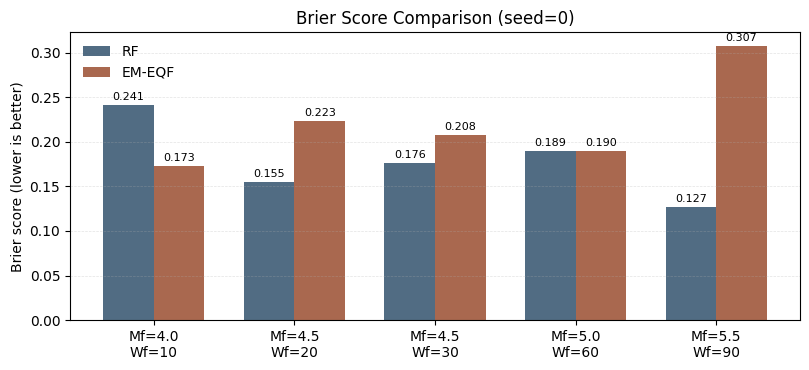

Saved Brier figure: /home/yzzhang/pjt/chuandian_eq/notebooks/figs/classifier_brier_reliability_single_seed/global/brier_score_seed_0.pdf


In [6]:
plot_df = metrics_df.copy()
plot_df['window_label'] = plot_df.apply(lambda r: f'Mf={r.Mf:.1f}\nWf={int(r.Tfore)}', axis=1)
window_labels = plot_df.drop_duplicates(['Mf', 'Tfore'])['window_label'].tolist()
models = ['RF', 'EM-EQF']
colors = {'RF': '#3E5C76', 'EM-EQF': '#A0583C'}

x = np.arange(len(window_labels))
width = 0.36

fig, ax = plt.subplots(figsize=(8.2, 3.8))
for offset, model_name in [(-width / 2, 'RF'), (width / 2, 'EM-EQF')]:
    values = (
        plot_df[plot_df['model'] == model_name]
        .set_index('window_label')
        .reindex(window_labels)['brier_score']
        .to_numpy()
    )
    bars = ax.bar(x + offset, values, width=width, label=model_name, color=colors[model_name], alpha=0.9)
    ax.bar_label(bars, fmt='%.3f', padding=2, fontsize=8)

ax.set_xticks(x)
ax.set_xticklabels(window_labels)
ax.set_ylabel('Brier score (lower is better)')
ax.set_title(f'Brier Score Comparison (seed={SINGLE_SEED})')
ax.grid(axis='y', linestyle='--', linewidth=0.5, alpha=0.35)
ax.legend(frameon=False)
fig.tight_layout()

brier_fig_path = FIG_EXPORT_DIR / f'brier_score_seed_{SINGLE_SEED}.pdf'
fig.savefig(brier_fig_path, bbox_inches='tight')
plt.show()
print(f'Saved Brier figure: {brier_fig_path}')

## 7) Reliability Diagrams

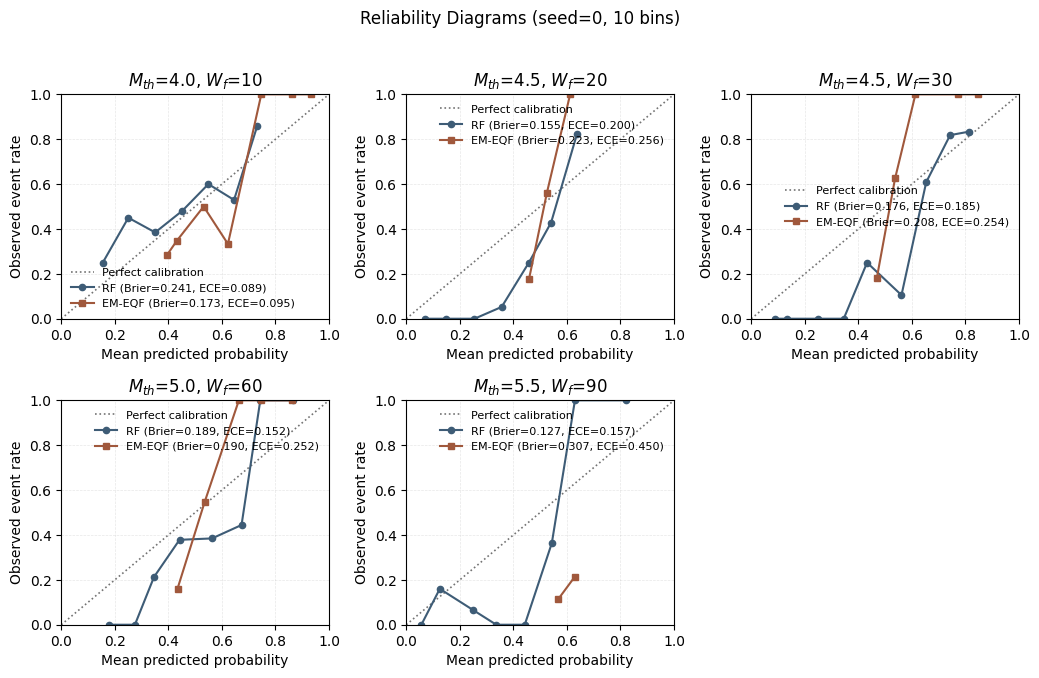

Saved reliability figure: /home/yzzhang/pjt/chuandian_eq/notebooks/figs/classifier_brier_reliability_single_seed/global/reliability_diagrams_seed_0.pdf


In [7]:
n_windows = len(EVAL_WINDOWS)
n_cols = min(3, n_windows)
n_rows = int(np.ceil(n_windows / n_cols))

fig, axes = plt.subplots(n_rows, n_cols, figsize=(3.5 * n_cols, 3.3 * n_rows), squeeze=False)
axes_flat = axes.ravel()

for ax, result in zip(axes_flat, prediction_results):
    mf = result['Mf']
    tfore = result['Tfore']
    window_metrics = metrics_df[(metrics_df['Mf'] == mf) & (metrics_df['Tfore'] == tfore)]

    ax.plot([0, 1], [0, 1], color='0.45', linestyle=':', linewidth=1.2, label='Perfect calibration')
    for model_name, marker in [('RF', 'o'), ('EM-EQF', 's')]:
        bins = calibration_df[
            (calibration_df['Mf'] == mf)
            & (calibration_df['Tfore'] == tfore)
            & (calibration_df['model'] == model_name)
            & (calibration_df['count'] > 0)
        ]
        brier = float(window_metrics.loc[window_metrics['model'] == model_name, 'brier_score'].iloc[0])
        ece = float(window_metrics.loc[window_metrics['model'] == model_name, 'ece'].iloc[0])
        ax.plot(
            bins['mean_predicted_probability'],
            bins['observed_event_rate'],
            marker=marker,
            linewidth=1.5,
            markersize=4.5,
            color=colors[model_name],
            label=f'{model_name} (Brier={brier:.3f}, ECE={ece:.3f})',
        )

    ax.set_xlim(0, 1)
    ax.set_ylim(0, 1)
    ax.set_xlabel('Mean predicted probability')
    ax.set_ylabel('Observed event rate')
    ax.set_title(rf'$M_{{th}}$={mf:.1f}, $W_f$={int(tfore)}')
    ax.grid(True, linestyle='--', linewidth=0.5, alpha=0.3)
    ax.legend(frameon=False, fontsize=8)

for ax in axes_flat[n_windows:]:
    ax.axis('off')

fig.suptitle(f'Reliability Diagrams (seed={SINGLE_SEED}, {N_BINS} bins)', y=1.02)
fig.tight_layout()

reliability_fig_path = FIG_EXPORT_DIR / f'reliability_diagrams_seed_{SINGLE_SEED}.pdf'
fig.savefig(reliability_fig_path, bbox_inches='tight')
plt.show()
print(f'Saved reliability figure: {reliability_fig_path}')

## 8) Inspect Reliability Bin Table

In [8]:
# Empty bins are retained in calibration_df with NaN rates; filter count > 0 for plotted points.
display(calibration_df.head(20))

,Mf,Tfore,seed,model,bin,bin_left,bin_right,count,mean_predicted_probability,observed_event_rate
0,4.0,10,0,RF,0,0.0,0.1,0,NaN,NaN
1,4.0,10,0,RF,1,0.1,0.2,4,0.155000,0.250000
2,4.0,10,0,RF,2,0.2,0.3,20,0.250500,0.450000
3,4.0,10,0,RF,3,0.3,0.4,13,0.350769,0.384615
4,4.0,10,0,RF,4,0.4,0.5,27,0.452593,0.481481
5,4.0,10,0,RF,5,0.5,0.6,35,0.549429,0.600000
6,4.0,10,0,RF,6,0.6,0.7,34,0.645294,0.529412
7,4.0,10,0,RF,7,0.7,0.8,14,0.731429,0.857143
8,4.0,10,0,RF,8,0.8,0.9,0,NaN,NaN
9,4.0,10,0,RF,9,0.9,1.0,0,NaN,NaN
